# 01 — EDA
Exploratory analysis for PD credit scoring sample / Lending Club-compatible data.

**Run cells top-to-bottom.** The first code cell installs missing packages into the active kernel.


In [1]:
# 0) Setup: path + auto-install EDA packages into THIS kernel
import sys
from pathlib import Path

_here = Path.cwd().resolve()
for _cand in [_here, _here.parent, _here.parent.parent]:
    if (_cand / "src").is_dir() and (_cand / "scripts").is_dir():
        ROOT = _cand
        break
else:
    ROOT = _here.parent

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.bootstrap import ensure_eda_deps, setup_project_path
setup_project_path()
ensure_eda_deps()
print("ROOT =", ROOT)
print("Ready.")

All required packages already installed.
ROOT = C:\Users\pc\Downloads\credit-scoring-uplift-master
Ready.


In [2]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

DATA = ROOT / "data"
sample = DATA / "sample_applications.csv"
if not sample.exists():
    from scripts.generate_sample_data import generate
    DATA.mkdir(exist_ok=True)
    generate(5000).to_csv(sample, index=False)
    print("generated", sample)
df = pd.read_csv(sample)
df.head()

,id,member_id,loan_amnt,term,int_rate,annual_inc,emp_length,home_ownership,purpose,dti,fico_range_low,fico_range_high,open_acc,delinq_2yrs,revol_bal,inq_last_6mths,issue_d,loan_status
0,1,376405,7304.91,60,23.50,30913.92,5 years,MORTGAGE,home_improvement,14.30,703,707,4,3,11152.66,1,Apr-2021,Charged Off
1,2,906194,23008.75,36,18.49,73764.16,< 1 year,RENT,medical,44.00,706,710,5,2,52059.86,0,Apr-2023,Fully Paid
2,3,504610,9515.15,36,14.53,28532.14,10+ years,MORTGAGE,other,35.84,812,816,13,2,16033.78,5,Dec-2022,Current
3,4,348250,34099.74,60,11.53,43093.84,5 years,MORTGAGE,home_improvement,42.46,602,606,15,1,86106.50,0,Apr-2022,In Grace Period
4,5,395470,33736.14,36,12.59,37657.10,10+ years,MORTGAGE,debt_consolidation,37.26,695,699,9,0,25014.71,5,Apr-2022,Current


In [3]:
print(df.shape)
print(df.dtypes)
df.describe(include="all").T.head(20)

(4000, 18)
id                   int64
member_id            int64
loan_amnt          float64
term                 int64
int_rate           float64
annual_inc         float64
emp_length          object
home_ownership      object
purpose             object
dti                float64
fico_range_low       int64
fico_range_high      int64
open_acc             int64
delinq_2yrs          int64
revol_bal          float64
inq_last_6mths       int64
issue_d             object
loan_status         object
dtype: object


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,4000.0,NaN,NaN,NaN,2000.5,1154.844867,1.0,1000.75,2000.5,3000.25,4000.0
member_id,4000.0,NaN,NaN,NaN,543423.1665,259715.168875,100016.0,314547.25,544763.5,767654.75,999989.0
loan_amnt,4000.0,NaN,NaN,NaN,21075.467265,10940.104121,2015.84,11610.75,21338.885,30193.315,39999.13
term,4000.0,NaN,NaN,NaN,43.32,11.05116,36.0,36.0,36.0,60.0,60.0
int_rate,4000.0,NaN,NaN,NaN,15.07295,5.242706,6.0,10.525,15.15,19.6025,23.99
annual_inc,4000.0,NaN,NaN,NaN,54647.2566,26084.783309,15000.0,36288.0425,49434.89,66149.72,231960.15
emp_length,4000,4,5 years,1599,NaN,NaN,NaN,NaN,NaN,NaN,NaN
home_ownership,4000,4,MORTGAGE,1656,NaN,NaN,NaN,NaN,NaN,NaN,NaN
purpose,4000,6,home_improvement,679,NaN,NaN,NaN,NaN,NaN,NaN,NaN
dti,4000.0,NaN,NaN,NaN,24.91588,11.409837,5.0,14.93,24.92,34.6675,45.0


default rate 0.2025


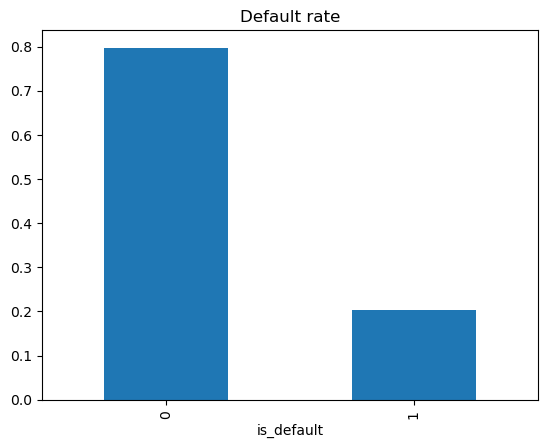

In [4]:
# Default rate proxy from loan_status if present
if "loan_status" in df.columns:
    defaults = {"Charged Off", "Default", "Late (31-120 days)"}
    df["is_default"] = df["loan_status"].isin(defaults).astype(int)
    print("default rate", df["is_default"].mean())
    df["is_default"].value_counts(normalize=True).plot(kind="bar", title="Default rate")
    plt.show()

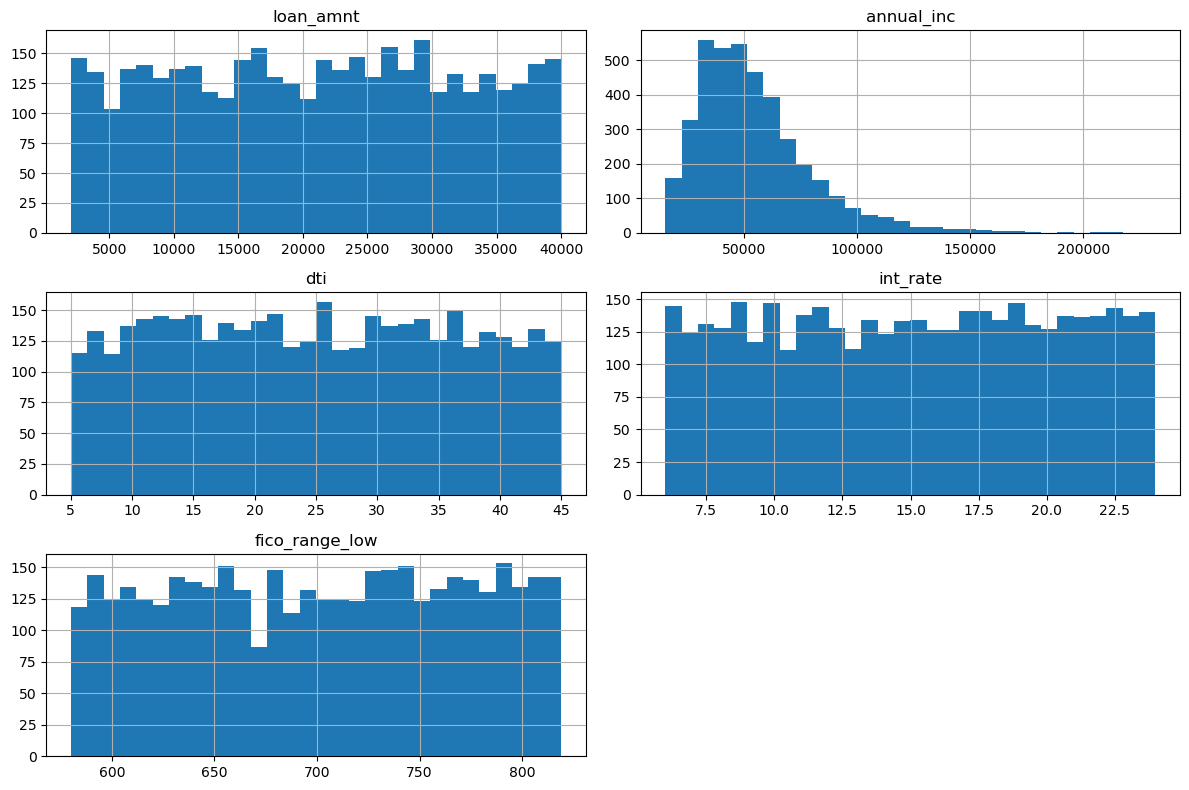

In [5]:
# Key numeric distributions
cols = [c for c in ["loan_amnt", "annual_inc", "dti", "int_rate", "fico_range_low"] if c in df.columns]
if cols:
    df[cols].hist(bins=30, figsize=(12, 8))
    plt.tight_layout()
    plt.show()

2021-01-01 00:00:00 2023-12-01 00:00:00


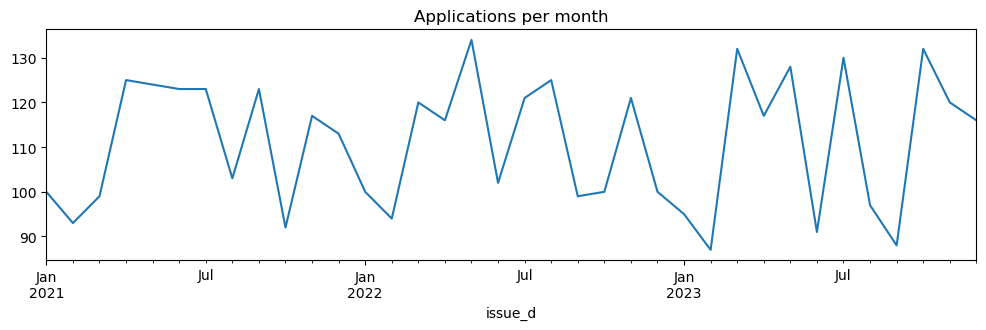

In [6]:
# Time coverage
if "issue_d" in df.columns:
    dates = pd.to_datetime(df["issue_d"], format="%b-%Y", errors="coerce")
    print(dates.min(), dates.max())
    dates.dt.to_period("M").value_counts().sort_index().plot(figsize=(12, 3), title="Applications per month")
    plt.show()